# FL Aggregation Comparison on CIFAR-10 Dataset, Non IID Client Distribution

### Introduction

Federated Learning (FL) enables multiple clients to collaboratively train a machine learning model while keeping their raw data locally on their devices. Unlike centralized learning, only model updates are exchanged between clients and the server, preserving data privacy and reducing communication of sensitive information.

In this experiment, a **Non-IID (Non-Independent and Identically Distributed)** data setting is considered, where each client receives data with different class distributions. This setup more closely resembles real-world federated learning scenarios, where users naturally generate data with varying characteristics and quantities.

### Objectives

* Simulate a realistic federated learning environment using Non-IID client data.
* Evaluate the impact of data heterogeneity on model performance.
* Compare the effectiveness of different federated aggregation methods.
* Analyze the role of adaptive gradient clipping in stabilizing local training.

### Aggregation Methods Compared

* FedAvg
* FedAvg + Gradient Clipping
* FedProx + Gradient Clipping
* Trimmed Mean + Gradient Clipping
* SCAFFOLD + Gradient Clipping

### Experimental Setup

* Dataset: CIFAR-10
* Data Distribution: Non-IID
* Model: Convolutional Neural Network (CNN)
* Evaluation Metrics:

  * Test Accuracy
  * Training Loss

### Adaptive Gradient Clipping

A data-driven gradient clipping strategy was employed to improve training stability. Gradient norms were collected during a short calibration run, and the clipping threshold was selected as the **95th percentile** of the observed gradient norm distribution. This approach reduces the influence of extreme gradients while preserving the majority of normal updates.

### Expected Challenges in Non-IID Learning

* Uneven class distributions across clients
* Increased client drift during local training
* Slower convergence compared to IID settings
* Greater sensitivity to aggregation strategies

As a result, advanced methods such as FedProx and SCAFFOLD are expected to play a more significant role in mitigating the effects of statistical heterogeneity and improving global model performance.


In [ ]:
!pip install torch torchvision -q

## Verify GPU

In [ ]:
import torch

print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: Tesla T4


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


## Import Libraries

In [ ]:
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import time
import os

## Settings

In [ ]:
# =========================================================
# TRAINING CONFIGURATION
# =========================================================

ROUNDS = 20
CLIENTS_PER_ROUND = 5
LOCAL_EPOCHS = 1
LR=0.005
MU=0.01
ALPHA=0.1

## Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
project_path = "/content/drive/MyDrive/FL_Project"

os.makedirs(project_path, exist_ok=True)

dataset_path = os.path.join(project_path, "datasets")

os.makedirs(dataset_path, exist_ok=True)

##Download CIFAR-10 Dataset

(Note that we have not used data augmentation (padding and horizontal flip))

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(
    root=dataset_path,
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root=dataset_path,
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [00:04<00:00, 42.3MB/s]


##Create Test Loader

In [ ]:
test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    drop_last=True,
    pin_memory=torch.cuda.is_available()
)

## Create IID Client Dataset:

In [ ]:
# =========================================================
# HIGHLY NON-IID CLIENT DATASET + LOADERS
# =========================================================

num_clients = 10
alpha = ALPHA
batch_size = 64

labels = np.array(train_dataset.targets)

client_indices = [[] for _ in range(num_clients)]

# ---------------------------------------------------------
# DIRICHLET NON-IID SPLIT
# ---------------------------------------------------------

for class_id in range(10):

    class_indices = np.where(labels == class_id)[0]

    np.random.shuffle(class_indices)

    proportions = np.random.dirichlet(
        np.repeat(alpha, num_clients)
    )

    proportions = (
        np.cumsum(proportions) * len(class_indices)
    ).astype(int)[:-1]

    split_class_indices = np.split(
        class_indices,
        proportions
    )

    for client_id in range(num_clients):

        client_indices[client_id].extend(
            split_class_indices[client_id]
        )

# ---------------------------------------------------------
# CREATE CLIENT LOADERS
# ---------------------------------------------------------

client_loaders = []

for client_id in range(num_clients):

    np.random.shuffle(client_indices[client_id])

    subset = Subset(
        train_dataset,
        client_indices[client_id]
    )

    loader = DataLoader(
        subset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True
    )

    client_loaders.append(loader)

print("Highly Non-IID Client Loaders Created!")

Highly Non-IID Client Loaders Created!


## Verify Client Data Sizes

In [ ]:
for i, loader in enumerate(client_loaders):
    print(f"Client {i}: {len(loader.dataset)} samples")

Client 0: 2395 samples
Client 1: 7259 samples
Client 2: 1387 samples
Client 3: 7864 samples
Client 4: 1001 samples
Client 5: 7420 samples
Client 6: 6983 samples
Client 7: 2059 samples
Client 8: 2134 samples
Client 9: 11498 samples


In [ ]:
# =========================================================
# PRINT CLIENT DATA DISTRIBUTION
# =========================================================

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

for client_id in range(num_clients):

    print(f"\n{'='*50}")
    print(f"CLIENT {client_id}")
    print(f"{'='*50}")

    client_labels = labels[client_indices[client_id]]

    class_counts = np.bincount(
        client_labels,
        minlength=10
    )

    for class_id in range(10):

        print(
            f"{class_names[class_id]:12s}: "
            f"{class_counts[class_id]}"
        )


CLIENT 0
airplane    : 0
automobile  : 0
bird        : 448
cat         : 4
deer        : 1642
dog         : 0
frog        : 0
horse       : 0
ship        : 0
truck       : 301

CLIENT 1
airplane    : 0
automobile  : 0
bird        : 0
cat         : 2
deer        : 45
dog         : 0
frog        : 81
horse       : 2748
ship        : 55
truck       : 4328

CLIENT 2
airplane    : 0
automobile  : 23
bird        : 0
cat         : 0
deer        : 0
dog         : 67
frog        : 822
horse       : 0
ship        : 136
truck       : 339

CLIENT 3
airplane    : 23
automobile  : 1087
bird        : 4481
cat         : 0
deer        : 1037
dog         : 617
frog        : 618
horse       : 0
ship        : 1
truck       : 0

CLIENT 4
airplane    : 7
automobile  : 4
bird        : 0
cat         : 293
deer        : 0
dog         : 0
frog        : 50
horse       : 1
ship        : 644
truck       : 2

CLIENT 5
airplane    : 0
automobile  : 1
bird        : 0
cat         : 0
deer        : 2129
dog         : 

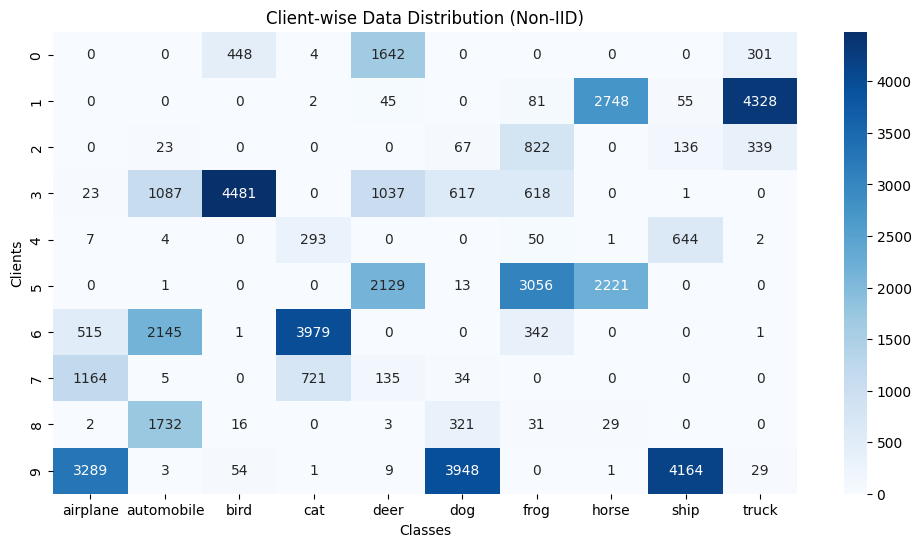

In [ ]:
# =========================================================
# CLIENT-WISE CLASS DISTRIBUTION
# =========================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

distribution = []

for client_id in range(num_clients):

    client_labels = labels[client_indices[client_id]]

    class_counts = np.bincount(
        client_labels,
        minlength=10
    )

    distribution.append(class_counts)

distribution = np.array(distribution)

df = pd.DataFrame(
    distribution,
    columns=[
        "airplane",
        "automobile",
        "bird",
        "cat",
        "deer",
        "dog",
        "frog",
        "horse",
        "ship",
        "truck"
    ]
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    df,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Classes")
plt.ylabel("Clients")
plt.title("Client-wise Data Distribution (Non-IID)")

plt.show()

## Define CNN Model

In [ ]:
class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.relu(self.conv1(x))
        x = self.pool(x)

        x = self.relu(self.conv2(x))
        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

## Scaffold control variates

In [ ]:
# =========================================================
# SCAFFOLD CONTROL VARIATES
# =========================================================

server_control = {}

temp_model = CNN().to(device)

for key, value in temp_model.state_dict().items():

    server_control[key] = torch.zeros_like(value)

client_controls = []

for _ in range(num_clients):

    local_control = {}

    for key, value in temp_model.state_dict().items():

        local_control[key] = torch.zeros_like(value)

    client_controls.append(local_control)

print("SCAFFOLD control variates initialized!")

SCAFFOLD control variates initialized!


## Define Global Model

In [ ]:
global_model = CNN().to(device)

print(global_model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (relu): ReLU()
)


## Define Evaluation Function

In [ ]:
def evaluate(model, test_loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    return accuracy

In [ ]:
# =========================================================
# GRADIENT NORM TRACKING
# =========================================================

gradient_norms = []

def get_gradient_norm(model):

    total_norm = 0.0

    for p in model.parameters():

        if p.grad is not None:

            param_norm = p.grad.data.norm(2)

            total_norm += param_norm.item() ** 2

    return total_norm ** 0.5

## Define Local Training Function (with Gradient Clipping)

In [ ]:
def local_train(
    model,
    global_model,
    loader,
    epochs=1,
    lr=LR,
    clip_grad=True,
    max_norm=1.0,
    fedprox=False,
    mu=MU
):

    model.train()

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9
    )

    epoch_loss = 0

    global_weights = copy.deepcopy(global_model.state_dict())

    for epoch in range(epochs):

        batch_losses = []

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            # =================================================
            # FEDPROX PROXIMAL TERM
            # =================================================

            if fedprox:

                proximal_term = 0.0

                for param, global_param in zip(
                    model.parameters(),
                    global_model.parameters()
                ):

                    proximal_term += torch.norm(
                        param - global_param
                    ) ** 2

                loss += (mu / 2) * proximal_term

            # =================================================
            # BACKPROPAGATION
            # =================================================

            loss.backward()

            # =================================================
            # RECORD GRADIENT NORM
            # =================================================

            grad_norm = get_gradient_norm(model)

            gradient_norms.append(grad_norm)


            # =================================================
            # GRADIENT CLIPPING
            # =================================================

            if clip_grad:

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=max_norm
                )

            optimizer.step()

            batch_losses.append(loss.item())

        epoch_loss += sum(batch_losses) / len(batch_losses)

    avg_loss = epoch_loss / epochs

    return model.state_dict(), avg_loss

# =========================================================
# 11. FEDAVG AGGREGATION
# =========================================================

def fedavg_aggregate(global_model, client_weights):

    global_dict = global_model.state_dict()

    for key in global_dict.keys():

        global_dict[key] = torch.stack([
            client_weights[i][key].float()
            for i in range(len(client_weights))
        ], 0).mean(0)

    global_model.load_state_dict(global_dict)

    return global_model

In [ ]:
# =========================================================
# SCAFFOLD LOCAL TRAINING
# =========================================================

def scaffold_local_train(
    model,
    global_model,
    loader,
    client_control,
    server_control,
    epochs=1,
    lr=LR,
    clip_grad=True,
    max_norm=1.0
):

    model.train()

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9
    )

    epoch_loss = 0

    global_weights = copy.deepcopy(
        global_model.state_dict()
    )

    for epoch in range(epochs):

        batch_losses = []

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            grad_norm = get_gradient_norm(model)

            gradient_norms.append(grad_norm)

            # =================================================
            # SCAFFOLD CORRECTION
            # =================================================

            with torch.no_grad():

                for name, param in model.named_parameters():

                    correction = (
                        server_control[name]
                        - client_control[name]
                    )

                    param.grad += correction.to(device)

            # =================================================
            # GRADIENT CLIPPING
            # =================================================

            if clip_grad:

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=max_norm
                )

            optimizer.step()

            batch_losses.append(loss.item())

        epoch_loss += sum(batch_losses) / len(batch_losses)

    avg_loss = epoch_loss / epochs

    # =====================================================
    # UPDATE CLIENT CONTROL VARIATE
    # =====================================================

    new_client_control = {}

    local_weights = model.state_dict()

    for key in client_control.keys():

        new_client_control[key] = (
            client_control[key]
            - server_control[key]
            + (global_weights[key] - local_weights[key]) / (epochs * lr)
        )

    return (
        model.state_dict(),
        avg_loss,
        new_client_control
    )

## Define FedAvg Aggregation

In [ ]:
def fedavg_aggregate(global_model, client_weights):

    global_dict = global_model.state_dict()

    for key in global_dict.keys():

        global_dict[key] = torch.stack([
            client_weights[i][key].float()
            for i in range(len(client_weights))
        ], 0).mean(0)

    global_model.load_state_dict(global_dict)

    return global_model

## 12. TRIMMED MEAN AGGREGATION (5%):

In [ ]:
def trimmed_mean_aggregate(
    global_model,
    client_weights,
    trim_ratio=0.05
):

    global_dict = global_model.state_dict()

    num_clients = len(client_weights)

    trim_k = max(1, int(num_clients * trim_ratio))

    for key in global_dict.keys():

        stacked = torch.stack([
            client_weights[i][key].float()
            for i in range(num_clients)
        ], 0)

        sorted_vals, _ = torch.sort(stacked, dim=0)

        trimmed = sorted_vals[
            trim_k : num_clients - trim_k
        ]

        global_dict[key] = trimmed.mean(0)

    global_model.load_state_dict(global_dict)

    return global_model

## Generic Federated Training Loop

In [ ]:
def federated_train(
    method_name="FedAvg",
    rounds=ROUNDS,
    clients_per_round=2,
    local_epochs=1,
    clip_grad=True,
    fedprox=False,
    trimmed_mean=False,
    scaffold=False,
    max_norm=1.0,
):

    print("\n" + "="*70)
    print(f"METHOD: {method_name}")
    print("="*70)

    global_model = CNN().to(device)

    global_accuracies = []

    round_losses = []

    best_accuracy = 0

    best_model_weights = None

    previous_accuracy = 0

    for round_num in range(rounds):

        start_time = time.time()

        print("\n" + "="*60)
        print(f"Round {round_num+1}/{rounds}")
        print("="*60)

        # =================================================
        # CLIENT SELECTION
        # =================================================

        selected_clients = np.random.choice(
            range(num_clients),
            clients_per_round,
            replace=False
        )

        print(f"\nSelected Clients: {selected_clients}\n")

        client_weights = []

        client_losses = []

        # =================================================
        # LOCAL TRAINING
        # =================================================

        for client_id in selected_clients:

          local_model = copy.deepcopy(global_model)

          # =====================================================
          # SCAFFOLD TRAINING
          # =====================================================

          if scaffold:

              weights, loss, updated_control = scaffold_local_train(
                  model=local_model,
                  global_model=global_model,
                  loader=client_loaders[client_id],
                  client_control=client_controls[client_id],
                  server_control=server_control,
                  epochs=local_epochs,
                  clip_grad=clip_grad
              )

              client_controls[client_id] = updated_control

          # =====================================================
          # NORMAL METHODS
          # =====================================================

          else:

              weights, loss = local_train(
              model=local_model,
              global_model=global_model,
              loader=client_loaders[client_id],
              epochs=local_epochs,
              clip_grad=clip_grad,
              max_norm=max_norm,
              fedprox=fedprox
          )

          client_weights.append(weights)

          client_losses.append(loss)

          print(f"Client {client_id} Loss: {loss:.4f}")

        # =================================================
        # AGGREGATION
        # =================================================

        if trimmed_mean:

            global_model = trimmed_mean_aggregate(
                global_model,
                client_weights,
                trim_ratio=0.05
            )

        else:

            global_model = fedavg_aggregate(
                global_model,
                client_weights
            )

        # =================================================
        # EVALUATE GLOBAL MODEL
        # =================================================

        accuracy = evaluate(global_model, test_loader)

        global_accuracies.append(accuracy)

        avg_client_loss = sum(client_losses) / len(client_losses)

        round_losses.append(avg_client_loss)

        accuracy_change = accuracy - previous_accuracy

        if accuracy > best_accuracy:

            best_accuracy = accuracy

            best_model_weights = copy.deepcopy(
                global_model.state_dict()
            )

        round_duration = time.time() - start_time

        # =================================================
        # ROUND SUMMARY
        # =================================================

        print("\n" + "-"*20 + " ROUND SUMMARY " + "-"*20)

        print(f"\nAverage Client Loss : {avg_client_loss:.4f}")

        print(f"Global Accuracy     : {accuracy:.2f}%")

        print(f"Accuracy Change     : {accuracy_change:+.2f}%")

        print(f"Best Accuracy       : {best_accuracy:.2f}%")

        print(f"Round Duration      : {round_duration:.2f} sec")

        previous_accuracy = accuracy

    # =====================================================
    # LOAD BEST MODEL
    # =====================================================

    global_model.load_state_dict(best_model_weights)

    # =====================================================
    # SAVE MODEL
    # =====================================================

    save_path = os.path.join(
        project_path,
        f"{method_name}_best_model.pth"
    )

    torch.save(best_model_weights, save_path)

    print("\nTraining Complete!")

    print(f"Best Accuracy: {best_accuracy:.2f}%")

    return global_accuracies, round_losses


## CALIBRATION RUN


In [ ]:
gradient_norms = []

print("Running Calibration...")

_ = federated_train(
    method_name="Calibration",
    rounds=3,
    clients_per_round=CLIENTS_PER_ROUND,
    local_epochs=LOCAL_EPOCHS,
    clip_grad=True
)

import numpy as np

OPTIMAL_CLIP_NORM = np.percentile(
    gradient_norms,
    95
)

print("\n" + "="*60)
print(f"OPTIMAL CLIP NORM = {OPTIMAL_CLIP_NORM:.4f}")
print("="*60)

Running Calibration...

METHOD: Calibration

Round 1/3

Selected Clients: [5 1 0 7 3]

Client 5 Loss: 1.2145
Client 1 Loss: 0.9007
Client 0 Loss: 1.5047
Client 7 Loss: 1.5405
Client 3 Loss: 1.4159

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.3153
Global Accuracy     : 10.02%
Accuracy Change     : +10.02%
Best Accuracy       : 10.02%
Round Duration      : 13.37 sec

Round 2/3

Selected Clients: [6 7 8 9 5]

Client 6 Loss: 1.1273
Client 7 Loss: 1.4829
Client 8 Loss: 1.4742
Client 9 Loss: 1.0400
Client 5 Loss: 1.0355

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.2320
Global Accuracy     : 12.25%
Accuracy Change     : +2.23%
Best Accuracy       : 12.25%
Round Duration      : 12.10 sec

Round 3/3

Selected Clients: [4 8 9 1 3]

Client 4 Loss: 1.9577
Client 8 Loss: 0.7743
Client 9 Loss: 0.8799
Client 1 Loss: 0.8304
Client 3 Loss: 1.3086

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.15

## Plotting the histogram

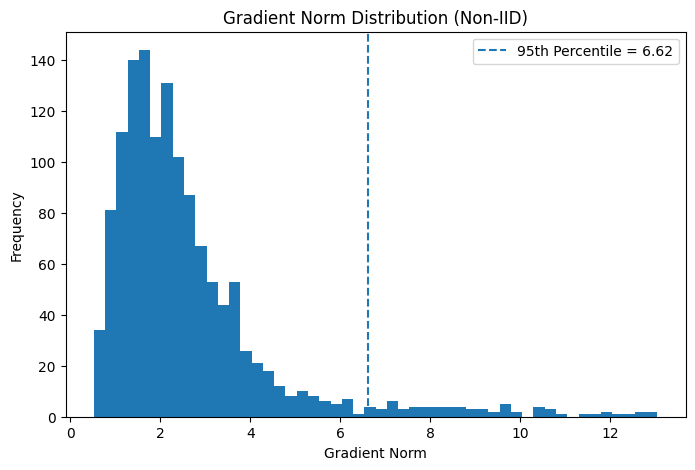

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(gradient_norms, bins=50)

plt.axvline(
    OPTIMAL_CLIP_NORM,
    linestyle='--',
    label=f'95th Percentile = {OPTIMAL_CLIP_NORM:.2f}'
)

plt.xlabel("Gradient Norm")
plt.ylabel("Frequency")
plt.title("Gradient Norm Distribution (Non-IID)")

plt.legend()
plt.show()

In [ ]:
# =========================================================
# 14. RUN EXPERIMENTS
# =========================================================

# ---------------------------------------------------------
# 1. FEDAVG (NO CLIPPING)
# ---------------------------------------------------------

fedavg_acc, fedavg_loss = federated_train(
    method_name="FedAvg_NoClipping",
    clip_grad=False,
    fedprox=False,
    trimmed_mean=False,
    rounds=ROUNDS,
  clients_per_round=CLIENTS_PER_ROUND,
  local_epochs=LOCAL_EPOCHS,
     max_norm=OPTIMAL_CLIP_NORM
)



METHOD: FedAvg_NoClipping

Round 1/20

Selected Clients: [2 4 8 9 7]

Client 2 Loss: 1.7010
Client 4 Loss: 1.8678
Client 8 Loss: 1.0838
Client 9 Loss: 0.9347
Client 7 Loss: 1.4244

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.4023
Global Accuracy     : 18.56%
Accuracy Change     : +18.56%
Best Accuracy       : 18.56%
Round Duration      : 7.56 sec

Round 2/20

Selected Clients: [4 0 7 8 5]

Client 4 Loss: 1.0632
Client 0 Loss: 1.2293
Client 7 Loss: 1.0089
Client 8 Loss: 0.7968
Client 5 Loss: 1.1262

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.0449
Global Accuracy     : 10.02%
Accuracy Change     : -8.54%
Best Accuracy       : 18.56%
Round Duration      : 7.83 sec

Round 3/20

Selected Clients: [5 9 4 3 6]

Client 5 Loss: 1.0021
Client 9 Loss: 0.8048
Client 4 Loss: 1.3604
Client 3 Loss: 1.2652
Client 6 Loss: 0.8518

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.0569
Global Accura

In [ ]:
# ---------------------------------------------------------
# 2. FEDAVG + CLIPPING
# ---------------------------------------------------------

fedavg_clip_acc, fedavg_clip_loss = federated_train(
    method_name="FedAvg_Clipping",
    clip_grad=True,
    fedprox=False,
    rounds=ROUNDS,
    clients_per_round=CLIENTS_PER_ROUND,
    local_epochs=LOCAL_EPOCHS,
    trimmed_mean=False,
    max_norm=OPTIMAL_CLIP_NORM
)



METHOD: FedAvg_Clipping

Round 1/20

Selected Clients: [7 2 0 6 8]

Client 7 Loss: 1.3031
Client 2 Loss: 1.6426
Client 0 Loss: 1.2925
Client 6 Loss: 1.0477
Client 8 Loss: 1.0549

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.2681
Global Accuracy     : 10.20%
Accuracy Change     : +10.20%
Best Accuracy       : 10.20%
Round Duration      : 12.01 sec

Round 2/20

Selected Clients: [1 4 7 0 3]

Client 1 Loss: 0.7205
Client 4 Loss: 1.5048
Client 7 Loss: 1.0342
Client 0 Loss: 1.0515
Client 3 Loss: 1.3021

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.1226
Global Accuracy     : 14.66%
Accuracy Change     : +4.47%
Best Accuracy       : 14.66%
Round Duration      : 8.05 sec

Round 3/20

Selected Clients: [2 5 4 6 0]

Client 2 Loss: 1.2786
Client 5 Loss: 1.0610
Client 4 Loss: 1.2955
Client 6 Loss: 0.8764
Client 0 Loss: 0.8548

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.0733
Global Accurac

In [ ]:
# ---------------------------------------------------------
# 3. FEDPROX + CLIPPING
# ---------------------------------------------------------

fedprox_acc, fedprox_loss = federated_train(
    method_name="FedProx_Clipping",
    clip_grad=True,
    fedprox=True,
    rounds=ROUNDS,
    clients_per_round=CLIENTS_PER_ROUND,
    local_epochs=LOCAL_EPOCHS,
    trimmed_mean=False,
    max_norm=OPTIMAL_CLIP_NORM
)



METHOD: FedProx_Clipping

Round 1/20

Selected Clients: [5 1 3 9 8]

Client 5 Loss: 1.1778
Client 1 Loss: 0.7937
Client 3 Loss: 1.3959
Client 9 Loss: 0.9625
Client 8 Loss: 1.1475

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.0955
Global Accuracy     : 17.99%
Accuracy Change     : +17.99%
Best Accuracy       : 17.99%
Round Duration      : 15.32 sec

Round 2/20

Selected Clients: [7 0 4 3 1]

Client 7 Loss: 1.2357
Client 0 Loss: 1.0131
Client 4 Loss: 1.5372
Client 3 Loss: 1.2028
Client 1 Loss: 0.5845

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.1147
Global Accuracy     : 17.27%
Accuracy Change     : -0.72%
Best Accuracy       : 17.99%
Round Duration      : 9.85 sec

Round 3/20

Selected Clients: [0 7 1 3 4]

Client 0 Loss: 0.8606
Client 7 Loss: 0.9014
Client 1 Loss: 0.5531
Client 3 Loss: 1.1436
Client 4 Loss: 1.0574

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 0.9032
Global Accura

In [ ]:
# ---------------------------------------------------------
# 4. TRIMMED MEAN + CLIPPING
# ---------------------------------------------------------

trimmed_acc, trimmed_loss = federated_train(
    method_name="TrimmedMean_Clipping",
    clip_grad=True,
    fedprox=False,
    rounds=ROUNDS,
    clients_per_round=CLIENTS_PER_ROUND,
    local_epochs=LOCAL_EPOCHS,
    trimmed_mean=True,
     max_norm=OPTIMAL_CLIP_NORM
)


METHOD: TrimmedMean_Clipping

Round 1/20

Selected Clients: [9 1 8 2 3]

Client 9 Loss: 0.9347
Client 1 Loss: 0.7770
Client 8 Loss: 1.0402
Client 2 Loss: 1.7007
Client 3 Loss: 1.3611

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.1627
Global Accuracy     : 15.19%
Accuracy Change     : +15.19%
Best Accuracy       : 15.19%
Round Duration      : 12.04 sec

Round 2/20

Selected Clients: [0 2 1 9 7]

Client 0 Loss: 1.1595
Client 2 Loss: 1.2650
Client 1 Loss: 0.6312
Client 9 Loss: 0.8190
Client 7 Loss: 1.4167

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.0583
Global Accuracy     : 10.02%
Accuracy Change     : -5.18%
Best Accuracy       : 15.19%
Round Duration      : 10.41 sec

Round 3/20

Selected Clients: [9 1 3 5 2]

Client 9 Loss: 0.7636
Client 1 Loss: 0.5614
Client 3 Loss: 1.2773
Client 5 Loss: 1.0477
Client 2 Loss: 1.2476

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 0.9795
Global A

In [ ]:
# ---------------------------------------------------------
# 5. SCAFFOLD + CLIPPING
# ---------------------------------------------------------

scaffold_acc, scaffold_loss = federated_train(
    method_name="SCAFFOLD_Clipping",
    clip_grad=True,
    fedprox=False,
    trimmed_mean=False,
    rounds=ROUNDS,
    clients_per_round=CLIENTS_PER_ROUND,
    local_epochs=LOCAL_EPOCHS,
    scaffold=True,
    max_norm=OPTIMAL_CLIP_NORM
)


METHOD: SCAFFOLD_Clipping

Round 1/20

Selected Clients: [2 9 8 0 5]

Client 2 Loss: 1.8651
Client 9 Loss: 1.0109
Client 8 Loss: 1.3554
Client 0 Loss: 1.4645
Client 5 Loss: 1.2050

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.3802
Global Accuracy     : 11.80%
Accuracy Change     : +11.80%
Best Accuracy       : 11.80%
Round Duration      : 10.24 sec

Round 2/20

Selected Clients: [3 5 8 4 0]

Client 3 Loss: 1.3363
Client 5 Loss: 2.7090
Client 8 Loss: 3.5746
Client 4 Loss: 2.1024
Client 0 Loss: 2.8231

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 2.5091
Global Accuracy     : 11.11%
Accuracy Change     : -0.69%
Best Accuracy       : 11.80%
Round Duration      : 8.90 sec

Round 3/20

Selected Clients: [4 1 0 5 9]

Client 4 Loss: 2.2031
Client 1 Loss: 1.0050
Client 0 Loss: 1.9990
Client 5 Loss: 2.5379
Client 9 Loss: 2.6396

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 2.0769
Global Accur

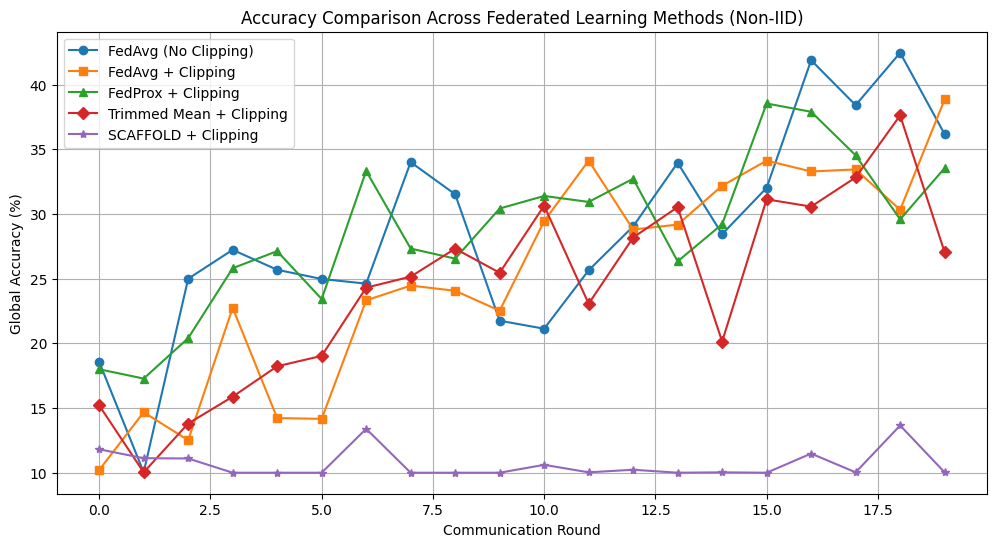

In [ ]:
# =========================================================
# ACCURACY COMPARISON
# =========================================================

plt.figure(figsize=(12, 6))

plt.plot(
    fedavg_acc,
    marker='o',
    label="FedAvg (No Clipping)"
)

plt.plot(
    fedavg_clip_acc,
    marker='s',
    label="FedAvg + Clipping"
)

plt.plot(
    fedprox_acc,
    marker='^',
    label="FedProx + Clipping"
)

plt.plot(
    trimmed_acc,
    marker='D',
    label="Trimmed Mean + Clipping"
)

plt.plot(
    scaffold_acc,
    marker='*',
    label="SCAFFOLD + Clipping"
)

plt.xlabel("Communication Round")
plt.ylabel("Global Accuracy (%)")
plt.title("Accuracy Comparison Across Federated Learning Methods (Non-IID)")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# =========================================================
# 16. SAVE PLOT
# =========================================================

plot_path = os.path.join(
    project_path,
    "fl_comparison_plot.png"
)

plt.savefig(plot_path)

print("\nPlot Saved To:")
print(plot_path)


Plot Saved To:
/content/drive/MyDrive/FL_Project/fl_comparison_plot.png


<Figure size 640x480 with 0 Axes>

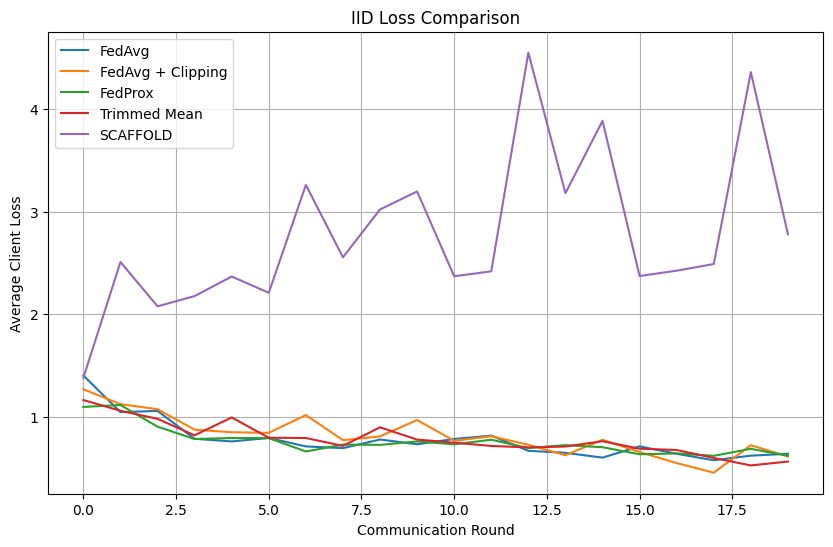

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(fedavg_loss, label="FedAvg")
plt.plot(fedavg_clip_loss, label="FedAvg + Clipping")
plt.plot(fedprox_loss, label="FedProx")
plt.plot(trimmed_loss, label="Trimmed Mean")
plt.plot(scaffold_loss, label="SCAFFOLD")

plt.xlabel("Communication Round")
plt.ylabel("Average Client Loss")
plt.title("IID Loss Comparison")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# =========================================================
# RESULTS COMPARISON TABLE
# =========================================================

import pandas as pd
import numpy as np

results_df = pd.DataFrame({

    "Method": [
        "FedAvg (No Clipping)",
        "FedAvg + Clipping",
        "FedProx + Clipping",
        "Trimmed Mean + Clipping",
        "SCAFFOLD + Clipping"
    ],

    "Best Accuracy (%)": [
        max(fedavg_acc),
        max(fedavg_clip_acc),
        max(fedprox_acc),
        max(trimmed_acc),
        max(scaffold_acc)
    ],

    "Final Accuracy (%)": [
        fedavg_acc[-1],
        fedavg_clip_acc[-1],
        fedprox_acc[-1],
        trimmed_acc[-1],
        scaffold_acc[-1]
    ],

    "Minimum Loss": [
        min(fedavg_loss),
        min(fedavg_clip_loss),
        min(fedprox_loss),
        min(trimmed_loss),
        min(scaffold_loss)
    ],

    "Final Loss": [
        fedavg_loss[-1],
        fedavg_clip_loss[-1],
        fedprox_loss[-1],
        trimmed_loss[-1],
        scaffold_loss[-1]
    ]

})

results_df = results_df.round(4)

results_df = results_df.sort_values(
    by="Best Accuracy (%)",
    ascending=False
)

display(results_df)

,Method,Best Accuracy (%),Final Accuracy (%),Minimum Loss,Final Loss
0,FedAvg (No Clipping),42.4679,36.1679,0.5756,0.6385
1,FedAvg + Clipping,38.8522,38.8522,0.4539,0.6129
2,FedProx + Clipping,38.5417,33.5437,0.6187,0.6193
3,Trimmed Mean + Clipping,37.6202,27.0333,0.5251,0.5629
4,SCAFFOLD + Clipping,13.6418,10.0160,1.3802,2.7804


## Conclusion

The Non-IID experiments highlight the challenges introduced by data heterogeneity in federated learning. Unlike the IID setting, where most methods achieved similar performance, the Non-IID distribution resulted in greater fluctuations in accuracy and slower convergence due to differences in local client data distributions.

### Key Findings

- **FedAvg (No Clipping)** achieved the highest peak accuracy (**42.47%**) among all methods, demonstrating that standard federated averaging can still perform competitively despite client heterogeneity.
- **FedAvg + Gradient Clipping** achieved the highest final accuracy (**38.85%**) while maintaining stable convergence and one of the lowest loss values, indicating that adaptive gradient clipping helped mitigate unstable client updates.
- **FedProx + Gradient Clipping** achieved a similar performance (**38.54%** best accuracy), suggesting that proximal regularization can partially reduce the impact of client drift in heterogeneous environments.
- **Trimmed Mean + Gradient Clipping** achieved **37.62%** peak accuracy and the lowest final loss (**0.56**), showing good robustness against noisy client updates but without a significant accuracy advantage.
- **SCAFFOLD + Gradient Clipping** performed poorly, reaching only **13.64%** accuracy and exhibiting highly unstable loss behavior. The control variate corrections were unable to effectively compensate for the severe data heterogeneity under the chosen experimental configuration.

### Accuracy Analysis

The accuracy curves exhibit substantially higher variability than in the IID case, reflecting the challenges posed by non-uniform client data distributions. FedAvg, FedAvg + Clipping, FedProx, and Trimmed Mean all demonstrated gradual improvement throughout training, although their trajectories were less smooth and more fluctuating than those observed under IID conditions. Among these methods, FedAvg achieved the highest peak accuracy, while FedAvg + Clipping maintained the most consistent final performance.

### Loss Analysis

The loss curves show that FedAvg, FedAvg + Clipping, FedProx, and Trimmed Mean converged to similar loss values below 0.7, indicating effective learning despite the heterogeneous data distribution. In contrast, SCAFFOLD maintained significantly higher and highly unstable loss values throughout training, suggesting poor convergence and ineffective adaptation to the Non-IID setting.

### Comparison with the IID Scenario

Compared to the IID experiments, all methods experienced a noticeable reduction in accuracy. This performance degradation is expected because clients trained on different data distributions, leading to greater client drift and more challenging global model aggregation. The results emphasize the importance of stabilization techniques such as gradient clipping and robust aggregation when dealing with heterogeneous federated data.

### Overall Conclusion

For the Non-IID setting, **FedAvg + Gradient Clipping emerged as the most balanced approach**, achieving the highest final accuracy while maintaining stable convergence and low loss. FedProx and Trimmed Mean also demonstrated competitive performance, whereas SCAFFOLD struggled significantly under the current experimental configuration. These results confirm that data heterogeneity remains one of the primary challenges in federated learning and that adaptive gradient clipping can contribute to improved training stability in realistic Non-IID environments.